# K-Means Clustering

Implementation of the K-Means algorithm from scratch using only Python and NumPy.

K-Means is an unsupervised learning algorithm used for clustering. Given a dataset and a number of clusters `k`, the algorithm partitions the data into `k` groups by minimizing the intra-cluster variance (inertia).

The algorithm follows these steps:

1. **Initialization**: randomly select `k` data points as initial centroids.
2. **Assignment**: assign each sample to the nearest centroid.
3. **Update**: recompute each centroid as the mean of its assigned samples.
4. **Convergence**: repeat steps 2–3 until centroids stop moving (change below `tol`) or `max_iter` is reached.

To avoid poor initialization, the model runs `n_init` times and keeps the result with the lowest inertia.

Dataset used: synthetic blobs generated with `sklearn.datasets.make_blobs`.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Class

In [19]:
class KMeans():
    def __init__(self, k, max_iter=300, n_init=10, tol=1e-4):
        self.k = k
        self.max_iter = max_iter
        self.n_init = n_init
        self.tol = tol
        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None

    def _init_centroids(self, X):
        n_samples, n_features = X.shape
        first_indexes = np.random.choice(n_samples, size=self.k, replace=False)
        centroids = X[first_indexes]
        return centroids

    def _compute_distances(self, X, centroids):
        n_samples, n_features = X.shape
        X = X.reshape(n_samples, 1, n_features)
        distances = X - centroids
        distances = np.sqrt(np.sum(distances ** 2, axis=2))
        return distances

    def _assign_clusters(self, distances):
        labels = np.argmin(distances, axis=1)
        return labels

    def _update_centroids(self, X, labels):
        centroids = []
        for i in range(self.k):
            cluster_points = X[labels == i]
            centroids.append(np.mean(cluster_points, axis=0))
        return np.array(centroids)

    def _compute_inertia(self, X, centroids, labels):
        diff = X - centroids[labels]
        return np.sum(diff ** 2)

    def fit(self, X):
        best_inertia = np.inf
        best_centroids = None
        best_labels = None

        for init in range(self.n_init):
            centroids = self._init_centroids(X)
            for iter in range(self.max_iter):
                distances = self._compute_distances(X, centroids)
                labels = self._assign_clusters(distances)
                new_centroids = self._update_centroids(X, labels)
                if abs(new_centroids - centroids).max() < self.tol:
                    centroids = new_centroids
                    break
                centroids = new_centroids

            inertia = self._compute_inertia(X, centroids, labels)
            if inertia < best_inertia:
                best_inertia = inertia
                best_centroids = centroids
                best_labels = labels

        self.centroids_ = best_centroids
        self.labels_ = best_labels
        self.inertia_ = best_inertia

    def predict(self, X):
        distances = self._compute_distances(X, self.centroids_)
        return self._assign_clusters(distances)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

# Generating data and fitting the model

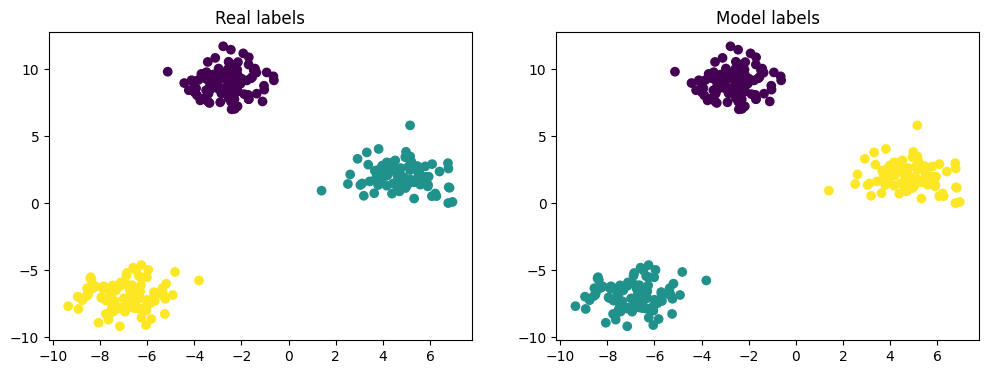

In [20]:
X, y_true = make_blobs(n_samples=300, centers=3, random_state=42)

model = KMeans(k=3)
labels = model.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X[:, 0], X[:, 1], c=y_true)
axes[0].set_title("Real labels")

axes[1].scatter(X[:, 0], X[:, 1], c=labels)
axes[1].set_title("Model labels")

plt.show()